# Experimental math and databases

## Experimental mathematics

Recall from the first day of class:

* You were given the definition of an unkown object and you had to count the number of such objects.

* The method we used was that of *experimental math*. We gathered data, and then we made a conjecture out of it.

* We would still need to prove our conjectures, but we at least had some intuition.

* The computer can be helpful in making connections or in disproving conjectures.

* There exists some databases that can help making connections, because they capture a lot of knowledge.

* You can find the documentation for the databases that have an interface with SageMath [online](https://doc.sagemath.org/html/en/reference/databases/index.html).

# Interface with databases

**Two principles of SageMath that we have encoutered before:**
- It works well with other open-source software
- SageMath serves as a knowledge base: it countains a lot of algorithms and description of objects

The same principle is true for **open databases**!

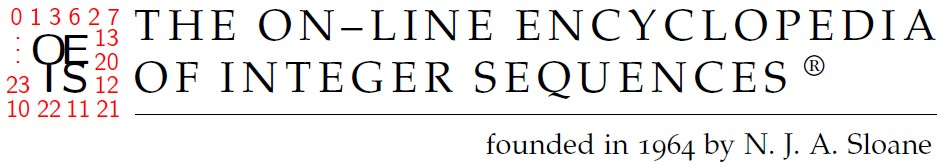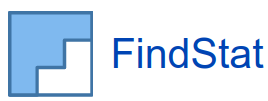

- OEIS
- FindStat
- A few other databases for knots, elliptic curves, etc.

# Online Encyclopedia of Integer Sequences: https://oeis.org/

- An *integer sequence* is a function $\{1,2,3,\ldots\} \to \mathbb{Z}$ (so it has a first term, and may have a last term; all images are integers).
- Likely the **most important database for math**.
- Very useful for number theory and combinatorics.
- Contains 394,262 sequences (as of yesterday)!
- Beyond the data, entries contain formulae, generating functions, properties and references

## OEIS examples

What is your favourite sequence?

In [70]:
# Input it here
# You can either enter a value, or a word that appears in either the title or the entry.
oeis("twin primes")

0: A001359: Lesser of twin primes.
1: A006512: Greater of twin primes.
2: A014574: Average of twin prime pairs.

Some famous sequences:

- The prime numbers, A000040
- The Fibonacci numbers, A000045

And sequences with two parameters also appear in the OEIS, as an array or a triangle.
- Pascal's triangle, A007318
- Triangle of Stirling numbers of second kind, A008277

In [35]:
oeis(7318)  # gives the tile of the sequence with ID A007318

A007318: Pascal's triangle read by rows: C(n,k) = binomial(n,k) = n!/(k!*(n-k)!), 0 <= k <= n.

In [40]:
oeis(7318).comments()[0:10]  # To discover the known meanings of sequence A007318

0: A. W. F. Edwards writes: "It [the triangle] was first written down long before 1654, the year in which Blaise Pascal wrote his Traité du triangle arithmétique, but it was this work that brought together all the different aspects of the numbers for the first time. In it Pascal developed the properties of the number as a piece of pure mathematics ... and then, in a series of appendices, showed how these properties were relevant to the study of the figurate numbers, to the theory of combinations, to the expansion of binomial expressions, and to the solution of an important problem in the theory of probability." (A. W. F. Edwards, Pascal's Arithmetical Triangle, Johns Hopkins University Press (2002), p. xiii)
1: Edwards reports that the naming of the triangle after Pascal was done first by Montmort in 1708 as the "Table de M. Pascal pour les combinaisons" and then by De Moivre in 1730 as the "Triangulum Arithmeticum PASCALANIUM". (Edwards, p. xiv)
2: In China, Yang Hui in 1261 listed th

### Identifying a sequence...

What is this?

```python
oeis(list(str(n(pi))))
```

In [17]:
# What is this?
oeis(list(str(n(pi))))

0: A000796: Decimal expansion of Pi (or digits of Pi).
1: A212131: Decimal expansion of k such that e^(k*sqrt(163)) = round(e^(Pi*sqrt(163))).
2: A112602: Erroneous version of decimal expansion of Pi (see A000796 for the correct version).

In [37]:
oeis(112602).browse()  # very intriguing name... Can you find the reason why this is there?
# 112602 used to appear when we were asking the query above
# Browse will open a tab on your browser with the corresponding page.

### $\pi$

> `oeis(list(str(n(pi))))`

Takes $\pi$, `n` expands its decimal (roughly to 16 digits of precision), `str` changes the number into a *string* (so a sequence) of characters, lists splits them. Asking the OEIS gives some choices for sequences.

In [78]:
print(pi)
print(n(pi))
print(str(n(pi)))
print(list(str(n(pi))))

pi
3.14159265358979
3.14159265358979
['3', '.', '1', '4', '1', '5', '9', '2', '6', '5', '3', '5', '8', '9', '7', '9']


## OEIS: 394,262 sequences?

- The OEIS is a **comprehensive** list of integer sequences.
- It contains pretty much any sequences you can think of, so it can be helpful for many math problems.
- Some sequences are not very relevant.
- If you know a relevant sequence, e.g. something that appears in a research paper, **add it!** The OEIS is written by volunteer mathematicians like you and I.

## OEIS

Any question on the OEIS?

# FindStat: [findstat.org](findstat.org)

- A **statistic** is a function from a combinatorial object $\mathcal{O}$ to a set of number.
  Most often, it is a function $\mathcal{O} \to \mathbb{N}$, but the image can be in $\mathbb{Q}$ or $\mathbb{Z}$.
- Combinatorial objects are the types we know: Permutations, subsets, compositions, graphs, ...
- Just like the OEIS, FindStat is a collaborative online database.
- It contains two types of functions: **statistics** and **maps** (function from a combinatorial object to another).
- Can be used with a detailed search engine on the interface.
- As of today, the database contains 1993 statistics and 336 maps on 24 collections by 112 contributors.
- On top of that, the search engine can compose the functions to give more relevant results.

## FindStat Interface

- Go to www.findstat.org
- Choose the **collection**: this is the type of combinatorial object, e.g. Permutations, graphs, compositions, etc.
- Enter the data manually in the form provided.

Or
- Call FindStat from SageMath!


In [2]:
# Example
# These two lines are needed for the execution of FindStat code with SageMath
from sage.databases.findstat import *
findstat()._allow_execution = True

list_for_search = []
for n in range(2,5):
    for p in Permutations(n):
        list_for_search.append((p, findmap(59)(findmap(66)(p))))
findmap(list_for_search, depth=2)  # to find a map

0: Mp00070 (quality [100])

This suggests that the map 70 is the same as the composition of 66 and 59 (this can be proven, but this requires knowledge of the objects).

In [3]:
for id in [59,66,70]:
    print(id, findmap(id).name())

59 Robinson-Schensted insertion tableau
66 inverse
70 Robinson-Schensted recording tableau


In [4]:
# Descents appeared in the practice midterm
findstat([(p, len(p.descents())) for p in Permutations(5)])[0:5]

0: St000021 (quality [100, 100])
1: St000325 with offset 1 (quality [100, 100])
2: St000470 with offset 1 (quality [100, 100])
3: St000021oMp00254 (quality [100, 100])
4: St000021oMp00241 (quality [100, 100])

This gives several options, of varying quality, but the lower quality is below. Here, there are several statistics that match perfectly (although sometimes with an offset, meaning a shift). We can ask FindStat what they are.

In [49]:
findstat(21)

St000021: The number of descents of a permutation.

In [5]:
# Less quality, as this statistic does not appear in FindStat
findstat([(p, len(p.descents())+len(p.peaks())) for p in Permutations(5)])

0: St000454oMp00184oMp00071 (quality [22, 100])

One can also get the SageMath code used to generate the statistic.

In [6]:
show(findstat(21).code())

'def statistic(x):\r\n    return x.number_of_descents()'

We can also ask for references.

In [7]:
findstat(21).references()  # [[/Permutations/Descents]] is an explanation of FindStat's website

0: [1]   [[/Permutations/Descents]]
1: [2]  Triangle of Eulerian numbers T(n,k) (n>=1, 1 <= k <= n) read by rows. [[OEIS:A008292]]
2: [3]  Brändén, P., Claesson, A., Mesh patterns and the expansion of permutation statistics as sums of permutation patterns [[arXiv:1102.4226]]

In [8]:
findstat(21).browse()  # opens a tab in a browser

# Discovering new math with FindStat

- Just like with the OEIS, FindStat serves as a repository for knowledge.
- We use it to know how to compute some maps, to know their properties or to get a list of common maps or statistics.

# Pitfalls with using databases
- The databases are not stored on your computer, so you *need* an internet connection to access them.
- If you are using SageMath on some servers (such as CoCalc), it does not let you access the internet (hence the databases) unless you pay.
- As with everything open (and everything not open as well), there may be errors in the content. However, both the OEIS and FindStat make much fewer mistakes than any mathematician working by hand!

# Takeaway

- Databases are incredibily helpful in finding bijections, or noticing correspondence in integer sequences.
- There is definitely something exciting in realizing that the data you have also appears somewhere else (just like when you hear sampling from a song in another one, and are trying to recognize it). It usually suggests **interesting connections**.

## A reference

Sara C. Billey and Bridget Eileen Tenner, *Fingerprint databases for theorems*, Notices of the American Mathematical Society 60 (2013), 1034-1039. Also available [on the ArXiv](https://arxiv.org/pdf/1304.3866).